In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
opo_file_path = "OPO1_OPO2_for_850cm-1.dat"
mix_file_path = "mix1_mix2_for_850cm-1.txt"
cars_file_path = "CARS_for_850cm-1.txt"
tis_wl, tis_bw = 805, 5

opo_data = np.loadtxt(opo_file_path)
mix_data = np.loadtxt(mix_file_path, skiprows=1)  # Skip the header row
cars_data = np.loadtxt(cars_file_path, skiprows=1)  # Skip the header row

#plt.plot(tis_data[:,0], tis_data[:,1], label='TIS', color='orange')

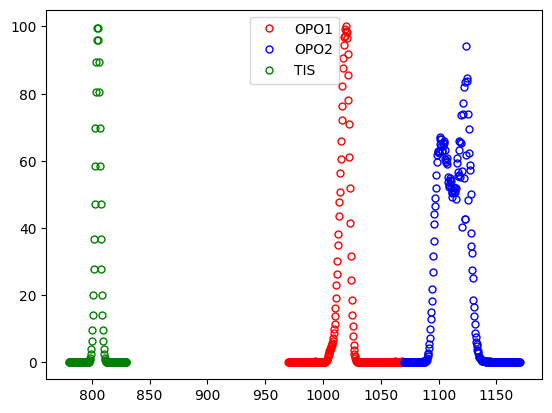

In [3]:
opo_data[:,1] = (opo_data[:,1] - np.min(opo_data[:,1])) * 100 / (np.max(opo_data[:,1]) - np.min(opo_data[:,1]))
opo1_data = opo_data[0:int(len(opo_data)/2)]
opo2_data = opo_data[int(len(opo_data)/2):]
#gaussian spectra for tis
wl = np.arange(tis_wl - 5*tis_bw, tis_wl + 5*tis_bw, opo1_data[1,0] - opo1_data[0,0])
tis_data = np.transpose(np.array([wl,100 * np.exp(-4*np.log(2) * ((wl - tis_wl) / tis_bw) ** 2)]))

plt.plot(opo1_data[:, 0], opo1_data[:, 1], 'ro', mfc = 'none', ms = 5, label='OPO1')
plt.plot(opo2_data[:, 0], opo2_data[:, 1], 'bo', mfc = 'none', ms = 5,label='OPO2')
plt.plot(tis_data[:,0], tis_data[:,1], 'go', mfc = 'none', ms = 5, label='TIS')
plt.legend()

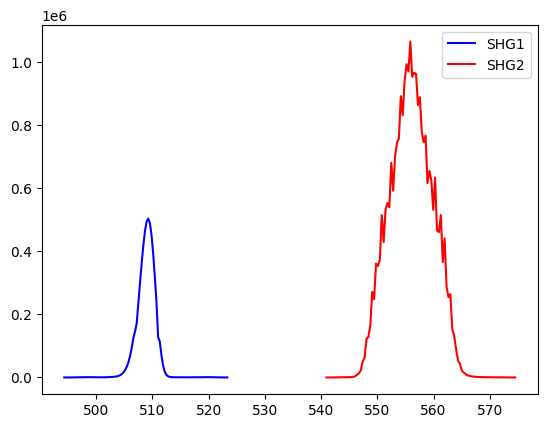

In [4]:
shg_points = []
dN = 1
for i in np.arange(0, len(opo1_data)-1, dN):
    for j in np.arange(0, len(opo1_data)-1, dN):
        shg_wl = 1 / (1/opo1_data[i,0] + 1/opo1_data[j,0])
        cnt = int(opo1_data[i,1] * opo1_data[j,1])
        if cnt > 0:
            #print(cnt)
            for k in range(cnt):
                shg_points.append(shg_wl)
hist1 = np.histogram(shg_points, bins=100)
shg_points = []
for i in np.arange(0, len(opo2_data)-1, dN):
    for j in np.arange(0, len(opo2_data)-1, dN):
        shg_wl = 1 / (1/opo2_data[i,0] + 1/opo2_data[j,0])
        cnt = int(opo2_data[i,1] * opo2_data[j,1])
        if cnt > 0:
            #print(cnt)
            for k in range(cnt):
                shg_points.append(shg_wl)
    
hist2 = np.histogram(shg_points, bins=100)

plt.plot(hist1[1][:-1], hist1[0], 'b-',label='SHG1')
plt.plot(hist2[1][:-1], hist2[0], 'r-',label='SHG2')
plt.legend()

In [5]:
def normalize(arr):
    return (arr - np.min(arr)) / (np.max(arr) - np.min(arr))

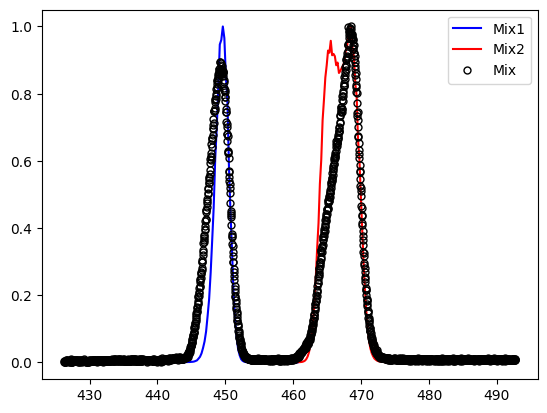

In [6]:
sum_points = []
dN = 1
for i in np.arange(0, len(opo1_data)-1, dN):
    for j in np.arange(0, len(tis_data)-1, dN):
        sum_wl = 1 / (1/opo1_data[i,0] + 1/tis_data[j,0])
        cnt = int(opo1_data[i,1] * tis_data[j,1])
        if cnt > 0:
            #print(cnt)
            for k in range(cnt):
                sum_points.append(sum_wl)
hist1 = np.histogram(sum_points, bins=100)

sum_points = []
for i in np.arange(0, len(opo2_data)-1, dN):
    for j in np.arange(0, len(tis_data)-1, dN):
        sum_wl = 1 / (1/opo2_data[i,0] + 1/tis_data[j,0])
        cnt = int(opo2_data[i,1] * tis_data[j,1])
        if cnt > 0:
            #print(cnt)
            for k in range(cnt):
                sum_points.append(sum_wl)
hist2 = np.histogram(sum_points, bins=100)

plt.plot(hist1[1][:-1], normalize(hist1[0]), 'b-',label='Mix1')
plt.plot(hist2[1][:-1], normalize(hist2[0]), 'r-',label='Mix2')
plt.plot(mix_data[:,0], normalize(mix_data[:,1]), 'ko', mfc = 'none', ms = 5, label='Mix')
plt.legend()

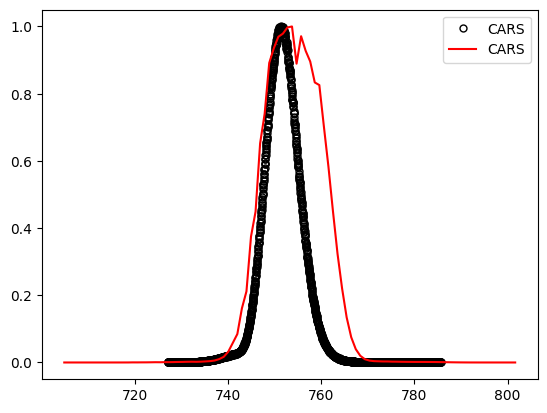

In [7]:
cars_points = []
dN = 5
for i in np.arange(0, len(opo1_data)-1, dN):
    for j in np.arange(0, len(opo2_data)-1, dN):
        for k in np.arange(0, len(tis_data)-1, dN):
            cars_wl = 1 / (1/tis_data[k,0] + 1/opo1_data[i,0] - 1/opo2_data[j,0])
            cnt = int(opo1_data[i,1] * tis_data[k,1] * opo2_data[j,1])
            if cnt > 0:
                #print(cnt)
                for l in range(cnt):
                    cars_points.append(cars_wl)
hist1 = np.histogram(cars_points, bins=100)

plt.plot(cars_data[:,0], normalize(cars_data[:,1]), 'ko', mfc = 'none', ms = 5, label='CARS')
plt.plot(hist1[1][:-1], normalize(hist1[0]), 'r-',label='CARS')
plt.legend()

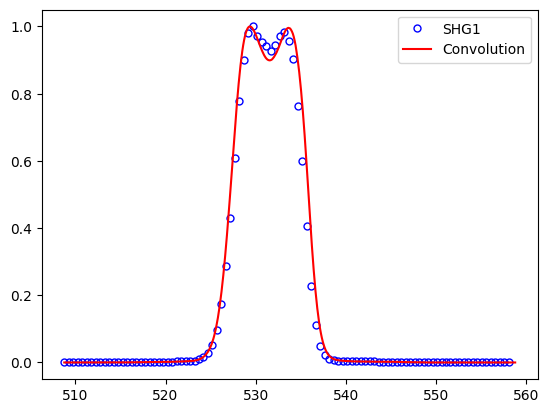

In [8]:
data1 = np.copy(opo1_data)
data2 = np.copy(opo2_data)
data1_min, data1_max = np.min(data1[:,0]), np.max(data1[:,0])
data2_min, data2_max = np.min(data2[:,0]), np.max(data2[:,0])
sum_points = []
dN = 1
for i in np.arange(0, len(data1)-1, dN):
    for j in np.arange(0, len(data2)-1, dN):
        sum_wl = 1 / (1/data1[i,0] + 1/data2[j,0])
        cnt = int(data1[i,1] * data2[j,1])
        if cnt > 0:
            for k in range(cnt+1):
                sum_points.append(sum_wl)
        else:
            sum_points.append(sum_wl)
    
hist1 = np.histogram(sum_points, bins=100)

plt.plot(hist1[1][:-1], normalize(hist1[0]), 'bo', mfc = 'none', ms = 5, label='SHG1')
conv = np.convolve(data1[:,1], data2[:,1], mode='full')
plt.plot(np.linspace(np.abs(1 / (1/data1_min + 1/data2_min)), np.abs(1 / (1/data2_max + 1/data1_max)), len(conv)), normalize(conv), 'r-', label='Convolution')
plt.legend()

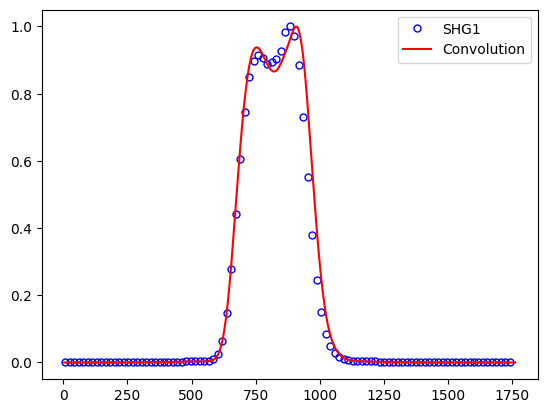

In [9]:
data1 = np.copy(opo1_data)
data2 = np.copy(opo2_data)
data1_min, data1_max = np.min(data1[:,0]), np.max(data1[:,0])
data2_min, data2_max = np.min(data2[:,0]), np.max(data2[:,0])
diff_points = []
dN = 1
for i in np.arange(0, len(data1)-1, dN):
    for j in np.arange(0, len(data2)-1, dN):
        diff_wl = 1E7 * (1/data1[i,0] - 1/data2[j,0])
        cnt = int(data1[i,1] * data2[j,1])
        if cnt > 0:
            for k in range(cnt+1):
                diff_points.append(diff_wl)
        else:
            diff_points.append(diff_wl)
    
hist1 = np.histogram(diff_points, bins=100)

plt.plot(hist1[1][:-1], normalize(hist1[0]), 'bo', mfc = 'none', ms = 5, label='SHG1')
conv = np.convolve(data1[:,1], np.flip(data2[:,1]), mode='full')
plt.plot(np.linspace(np.abs(1E7 * (1/data1_min - 1/data2_max)), np.abs(1E7 * (1/data2_min - 1/data1_max)), len(conv)), normalize(conv), 'r-', label='Convolution')
plt.legend()